### IBM QAOA Parameter Setting Analysis ###
This notebook produces tables and generates plots to analyze real IBM Qunatum hardware data while running QAOA on ensembles of the MaxCut problem. Various training strategies are utilized to determine the optimal parameters (angles of QAOA) before running them on hardware. The idea is to create a resource-cost estimation for these different parameter setting strategies and suggest best practices.

In [1]:
%load_ext autoreload
%autoreload 2

# Path imports
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# IBM QAOA package specific
from src.Processing import QAOAHardware, QAOATraining
from src.Processing import set_data_path
from src.Processing import load_problem_instance
from src.Processing import resolve_hardware_training_costs
from src.approx_ratio_calc import (
    extract_minmax_args,
    get_minmax,
    load_maxcut_instance_context,
    maxcut_approximation_ratio,
    maxcut_energy_from_bitstring,
)
from src.utils import (
    build_recommendation_data,
    is_empty_nested_list,
    counts_to_samples_df,
    make_asof_per_file,
    plot_ar_hist_by_training_method_with_points,
    plot_ibm_qaoa_overlay,
    plot_ibm_qaoa_performance_panels,
    plot_ibm_qaoa_recommendation,
    plot_ibm_qaoa_training_bricks,
    plot_training_bricks,
    prepare_ibm_qaoa_plot_data,
    prepare_training_bricks_data,
    print_budget_recommendations,
    sem,
    title_from_instance_names,
)

# General useful Python libraries
import pandas as pd 
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import numpy as np  
from pathlib import Path
from IPython.display import display
import math
import json

# Add stochastic-benchmark src to path and import related libraries
sys.path.append('../../src')
import stochastic_benchmark as SB
import bootstrap
import interpolate
import stats
from utils_ws import *
from plotting import Plotting
from plotting import ws_style

#### Data Analysis for IBM Quantum Hardware Data ####

In [2]:
# Select graph to explore
graph_type = "heavy_hex"  # line_to_full, random_regular, erdos_renyi

# Configure the QAOA-Parameter-Setting checkout.
DEFAULT_MAIN_REPO = Path("/mnt/c/Users/rames102/Desktop/QAOA-Parameter-Setting")
MAIN_REPO = Path(
    os.environ.get("QAOA_PARAMETER_SETTING_ROOT", str(DEFAULT_MAIN_REPO))
).expanduser()

# QAOA-Parameter-Setting directory specific paths
data_dir = str(MAIN_REPO / "data")
inst_path = str(MAIN_REPO / "instances")
minmax_path = str(MAIN_REPO / "data" / "minmax_cuts")

# Hardware-energy configuration
HARDWARE_ENERGY_MODE = "full"  # "full" or "top"
HARDWARE_TOP_PC = None

# Select hardware instance parameters to explore
p_list = [5, 10]  # heavy_hex 144 depths
num_nodes = 144
instance_list = list(range(10))
degree = None  # For Random Regular graphs
swap_layers = None  # For Line-to-Full graphs
ER_probability = None  # For Erdos-Renyi graphs

# Load graph instances for the above parameter combination
instance_paths_hardware = []

# Set option to display all rows of DataFrame
pd.set_option('display.max_rows', None)

# Set option to display all columns of DataFrame
pd.set_option('display.max_columns', None)

# Load instance file paths
instance_file_paths = []
for instance in instance_list:
    instance_path = load_problem_instance(inst_path, graph_type, num_nodes, instance, degree=str(degree), ER_probability=str(ER_probability), swap_layers=str(swap_layers))
    instance_file_paths.append(instance_path)

instance_path_map = {
    p.stem.split("_")[0].zfill(3): p
    for sublist in instance_file_paths
    for p in sublist
}

instance_context_cache = {}

# Load hardware data paths
for p in p_list:
    hardware_data_path = set_data_path(data_dir, True, False, graph_type)
    for instance in instance_list:
        instance_paths_hardware.extend(QAOAHardware.locate_hardware_instance(
            hardware_data_path,
            graph_type,
            str(instance),
            str(num_nodes),
            str(p),
            ER_probability=str(ER_probability),
            swap_layers=str(swap_layers),
            degree=str(degree),
        ))


In [3]:
all_instances_data_hardware = []

for instance_path in instance_paths_hardware:
    instance_number = Path(instance_path).name[:3]
    if instance_number not in instance_context_cache:
        instance_context_cache[instance_number] = load_maxcut_instance_context(
            instance_path_map[instance_number]
        )
    instance_context = instance_context_cache[instance_number]
    all_instances_data_hardware.extend(
        QAOAHardware.load_hardware_instance(
            instance_path,
            objective_from_bitstring=maxcut_energy_from_bitstring,
            objective_context=instance_context,
            energy_mode=HARDWARE_ENERGY_MODE,
            top_pc=HARDWARE_TOP_PC,
        )
    )

# Expand each object into data columns
all_data_dicts_hardware = []

for object in all_instances_data_hardware:
    data_dict_hardware = {
    "instance_name": object.instance_name,
    "QPU_time (s)": object.QPU_time,
    "num_shots": object.num_shots,
    "problem_class": object.problem_class,
    "training_method": object.training_method,
    "expected_energy": object.expected_energy,
    "file_name": object.file_name,
    "job_p": object.job_p,                 
    "training_p": object.training_p,       
    "counts": object.counts,
    "params": object.params,
    "trainer": object.trainer,
    }
    all_data_dicts_hardware.append(data_dict_hardware)

# Create a DataFrame for the extracted hardware data.
df_hardware = pd.DataFrame(all_data_dicts_hardware)

# Keep only MaxCut runs. Some hardware job files now mix in MIS-tagged metadata.
df_hardware = df_hardware[
    df_hardware["problem_class"].str.lower().eq("maxcut")
    & df_hardware["file_name"].str.contains("_MC_", na=False)
].copy()

In [4]:
# Compute approximation ratio for each object and append to the DataFrame
minmax_cache = {} # Since the same instance is present in multiple rows of the DataFrame, just load and store it once
approximation_ratio = []

for _, row in df_hardware.iterrows():
    file_name = row["file_name"]
    energy = row["expected_energy"] 
    instance_number = file_name[:3]
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes, ER_probability=str(ER_probability), swap_layers=str(swap_layers), degree=str(degree)) # Extract specific minmax_instance path
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path) # Cache args for the speciic instance
    min_cut, max_cut, sum_weights = minmax_cache[instance_number] # Extract minmax args for the specific instance
    approximation_ratio.append(maxcut_approximation_ratio(min_cut, max_cut, sum_weights, energy)) # Evlaute approximation ratio for that row
df_hardware["approximation_ratio"] = approximation_ratio

display(df_hardware.head())    


,instance_name,QPU_time (s),num_shots,problem_class,training_method,expected_energy,file_name,job_p,training_p,counts,params,trainer,approximation_ratio
0,000N144HH73_MC,1.148148,4096,maxcut,F_MPS_10,31.186444,000N144HH73_MC_F_MPS_optBD24_10.json,5,10,{'10110001011111101000111011110010011011011101...,"[5.106885164754779, 4.4136623127428445, 3.6842...",ScipyTrainer,0.749907
1,000N144HH73_MC,1.148148,4096,maxcut,F_PP_10,40.321201,000N144HH73_MC_F_PP_optMW6_10.json,5,10,{'01010011100010000011111101000101000001000000...,"[2.191296845097641, 0.48092590623290943, 0.350...",ScipyTrainer,0.823107
2,000N144HH73_MC,1.148148,4096,maxcut,I_MPS_10,22.017890,000N144HH73_MC_I_MPS_optBD24_10.json,5,10,{'01000010110010000011100011000101011001110011...,"[0.7876362055833895, 0.572027593061248, 0.5438...",ScipyTrainer,0.676437
3,000N144HH73_MC,1.148148,4096,maxcut,I_PP_10,41.798758,000N144HH73_MC_I_PP_optMW6_10.json,5,10,{'10001001100010000111100001110010100100111001...,"[0.5959603387169073, 0.4414919966934164, 0.329...",ScipyTrainer,0.834947
4,000N144HH73_MC,1.148148,4096,maxcut,TQA_PP_opt_5,39.584154,000N144HH73_MC_TQA_PP_optMW6_5.json,5,5,{'01011010100010001111100000110100010100111001...,"[1.056429177491575, 0.7986165781864637, 0.4831...",ScipyTrainer,0.817201


In [5]:
# Extract bitstrings
df_samples = counts_to_samples_df(df_hardware)
display(df_samples.head())

,instance_name,training_method,job_p,train_p,bitstring,count,prob
0,000N144HH73_MC,F_MPS_10,5,10,1011000101111110100011101111001001101101110100...,1,0.000244
1,000N144HH73_MC,F_MPS_10,5,10,1111010100100111000000101101110011110110010011...,1,0.000244
2,000N144HH73_MC,F_MPS_10,5,10,0000010001111101000011110010001000101100100000...,1,0.000244
3,000N144HH73_MC,F_MPS_10,5,10,0011000001111001111010001100010011001110001000...,1,0.000244
4,000N144HH73_MC,F_MPS_10,5,10,1100000000101001111010001000010011101110011000...,1,0.000244


In [6]:
minmax_cache = {}

ar_list_bitstring = []

for _, row in df_samples.iterrows():
    instance_name = row["instance_name"][:3]
    instance_number = str(instance_name).split("_")[0].zfill(3)  # "000"

    # Minmax cache 
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes, ER_probability=str(ER_probability), swap_layers=str(swap_layers), degree=str(degree))
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path)

    min_cut, max_cut, sum_weights = minmax_cache[instance_number]

    if instance_number not in instance_context_cache:
        instance_context_cache[instance_number] = load_maxcut_instance_context(
            instance_path_map[instance_number]
        )
    instance_context = instance_context_cache[instance_number]
    u = instance_context["u"]
    v = instance_context["v"]
    w = instance_context["w"]

    # Energy / AR
    bs = row["bitstring"][::-1]
    bits = np.fromiter((c == "1" for c in bs), dtype=np.int8)

    cut_val = float(np.sum(w * (bits[u] != bits[v])))
    ar = (cut_val - min_cut) / (max_cut - min_cut)

    ar_list_bitstring.append(ar)

df_samples["approximation_ratio"] = ar_list_bitstring


In [7]:
display(df_samples.head())

,instance_name,training_method,job_p,train_p,bitstring,count,prob,approximation_ratio
0,000N144HH73_MC,F_MPS_10,5,10,1011000101111110100011101111001001101101110100...,1,0.000244,0.707925
1,000N144HH73_MC,F_MPS_10,5,10,1111010100100111000000101101110011110110010011...,1,0.000244,0.691437
2,000N144HH73_MC,F_MPS_10,5,10,0000010001111101000011110010001000101100100000...,1,0.000244,0.730593
3,000N144HH73_MC,F_MPS_10,5,10,0011000001111001111010001100010011001110001000...,1,0.000244,0.725670
4,000N144HH73_MC,F_MPS_10,5,10,1100000000101001111010001000010011101110011000...,1,0.000244,0.748260


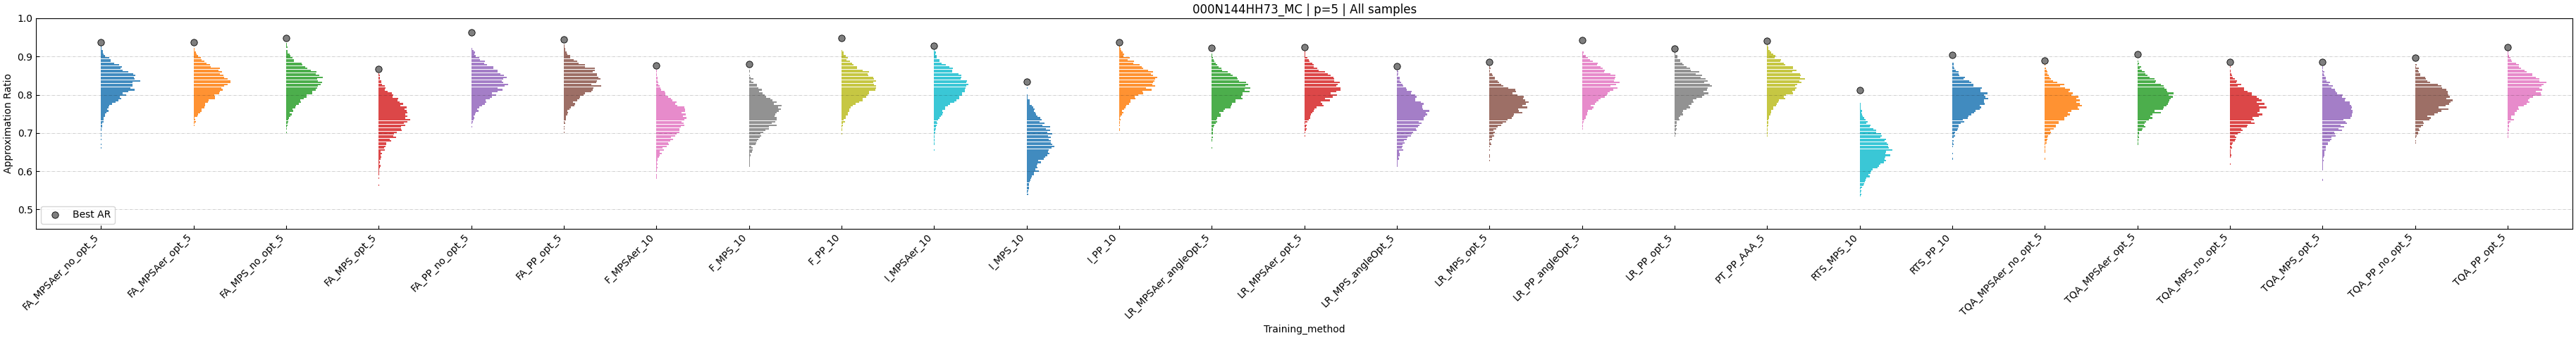

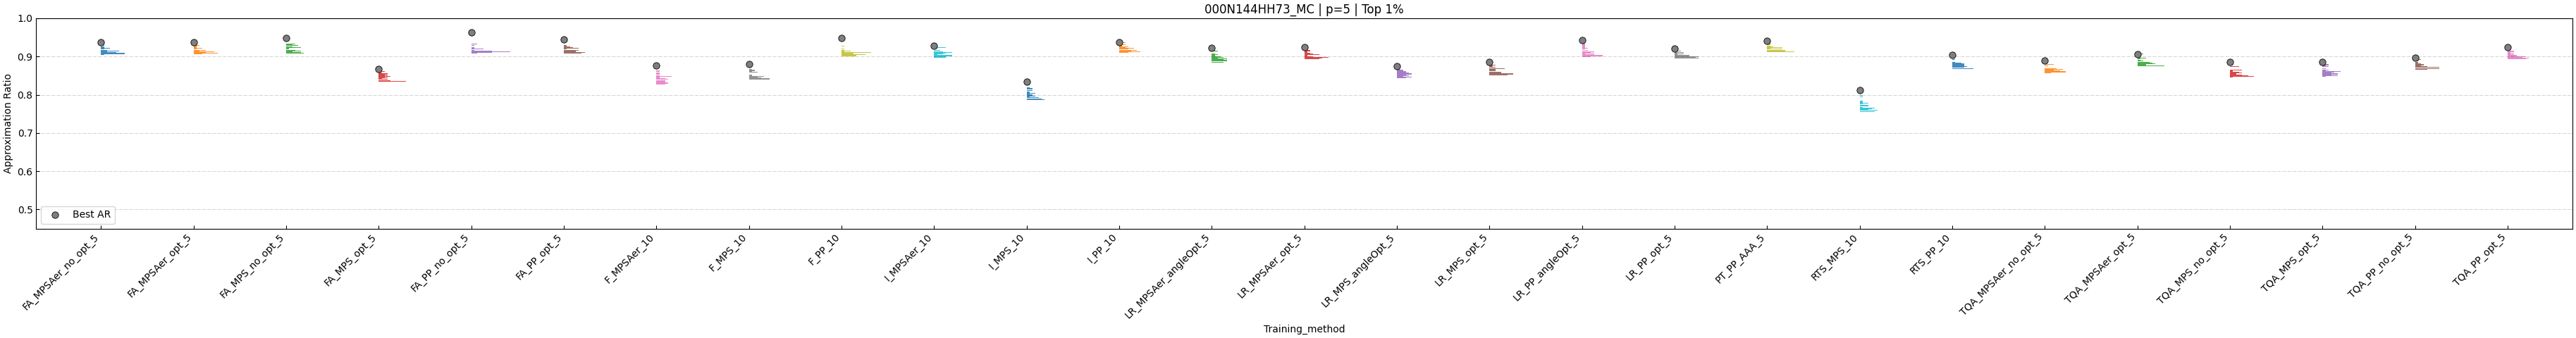

In [8]:
# Plot Distributions for each instance
plot_ar_hist_by_training_method_with_points(df_samples, instance_name="000N144HH73_MC", job_p=5, bins=100, symmetric=False, normalize="global")

#### Data Analysis for IBM Quantum QAOA Parameter Training Data ####

In [9]:
instance_paths_training = []

for p in p_list:
    training_data_path = set_data_path(data_dir, False, True, graph_type)
    for instance in instance_list:
        instance_paths_training.extend(QAOATraining.locate_training_instance(training_data_path, graph_type, instance, 
        num_nodes, p, ER_probability=str(ER_probability), swap_layers=str(swap_layers), degree=str(degree)))

In [10]:
all_instances_data_training = []

for instance_path in instance_paths_training:
    obj = QAOATraining.load_training_instance(instance_path)
    all_instances_data_training.append(obj)

# Expand each object into data columns
all_data_dicts_training = []

for obj in all_instances_data_training:
    data_dict_training = {
        "file_name": obj.file_name,
        "physical_training_file": obj.physical_file_name,
        "pre_processing_time": obj.pre_processing_time,
        "pre_processor_name": obj.pre_processor_name,
        "train_duration_per_iter": obj.train_duration_per_iter,
        "expected_energy_per_iter": obj.expected_energy_per_iter,
        "trainer_name_per_iter": obj.trainer_name_per_iter,
        "train_duration_per_layer": obj.train_duration_per_layer,
        "expected_energy_per_layer": obj.expected_energy_per_layer,
        "trainer_name_per_layer": obj.trainer_name_per_layer,
        "num_depth_iter": obj.num_depth_iter,
        "stage_summaries": obj.stage_summaries,
    }
    all_data_dicts_training.append(data_dict_training)

In [11]:
# Creata a DataFrame to document the raw extracted training data  
df_training = pd.DataFrame(all_data_dicts_training)

In [12]:
# Clean the DataFrame and report NaN to missing values
df_training = df_training.map(
    lambda x: np.nan if (x is None or x == [] or x == {} or is_empty_nested_list(x)) else x
)

In [13]:
# This cell basically converts the DataFrame from a nested structure to a flat structure for better analysis
flat_rows = []

for _, row in df_training.iterrows():
    file = row["file_name"]
    physical_file = row["physical_training_file"]

    outer_dur = row["train_duration_per_iter"]
    outer_eng = row["expected_energy_per_iter"]
    outer_trn = row["trainer_name_per_iter"]

    inner_dur   = row["train_duration_per_layer"]
    inner_eng   = row["expected_energy_per_layer"]
    inner_trn   = row["trainer_name_per_layer"]
    inner_depth = row["num_depth_iter"]

    if not isinstance(outer_dur, list):
        continue

    for i in range(len(outer_dur)):
        trn = outer_trn[i] if isinstance(outer_trn, list) and i < len(outer_trn) and isinstance(outer_trn[i], dict) else {}
        min_args = trn.get("minimize_args") if isinstance(trn.get("minimize_args"), dict) else {}
        opts = min_args.get("options") if isinstance(min_args.get("options"), dict) else {}

        flat_rows.append({
            "file_name": file,
            "physical_training_file": physical_file,
            "level": "outer",
            "stage": i,
            "iteration": i,
            "duration": outer_dur[i] if i < len(outer_dur) else np.nan,
            "energy": outer_eng[i] if isinstance(outer_eng, list) and i < len(outer_eng) else np.nan,
            "trainer": trn.get("trainer_name"),
            "trainer_name": trn.get("trainer_name"),
            "method": min_args.get("method"),
            "maxiter": opts.get("maxiter"),
            "depth_step": np.nan,
        })

        # nested lists
        dur_i   = inner_dur[i]   if isinstance(inner_dur, list)   and i < len(inner_dur)   and isinstance(inner_dur[i], list)   else []
        eng_i   = inner_eng[i]   if isinstance(inner_eng, list)   and i < len(inner_eng)   and isinstance(inner_eng[i], list)   else []
        trn_i   = inner_trn[i]   if isinstance(inner_trn, list)   and i < len(inner_trn)   and isinstance(inner_trn[i], list)   else []
        depth_i = inner_depth[i] if isinstance(inner_depth, list) and i < len(inner_depth) and isinstance(inner_depth[i], list) else []

        for dur, eng, trn2, depth in zip(dur_i, eng_i, trn_i, depth_i):
            trn2 = trn2 if isinstance(trn2, dict) else {}
            min_args2 = trn2.get("minimize_args") if isinstance(trn2.get("minimize_args"), dict) else {}
            opts2 = min_args2.get("options") if isinstance(min_args2.get("options"), dict) else {}

            flat_rows.append({
                "file_name": file,
                "physical_training_file": physical_file,
                "level": "inner",
                "stage": i,
                "iteration": i,
                "depth_step": depth,
                "duration": dur,
                "energy": eng,
                "trainer": trn2.get("trainer_name"),
                "trainer_name": trn2.get("trainer_name"),
                "method": min_args2.get("method"),
                "maxiter": opts2.get("maxiter"),
            })

df_flat = pd.DataFrame(flat_rows)

In [14]:
# Compute approximation ratio for each object and append to the DataFrame. Use the same cache created for hardware data
approximation_ratio_training = []

for _, row in df_flat.iterrows():
    file_name = row["file_name"]
    energy = row["energy"] 
    instance_number = file_name[:3]
    if instance_number not in minmax_cache:
        minmax_instance_path = get_minmax(minmax_path, graph_type, instance_number, num_nodes) # Extract specific minmax_instance path
        minmax_cache[instance_number] = extract_minmax_args(minmax_instance_path) # Cache args for the speciic instance
    min_cut, max_cut, sum_weights = minmax_cache[instance_number] # Extract minmax args for the specific instance
    approximation_ratio_training.append(maxcut_approximation_ratio(min_cut, max_cut, sum_weights, energy)) # Evlaute approximation ratio for that row
df_flat["approximation_ratio"] = approximation_ratio_training  

In [15]:
display(df_flat.head())

,file_name,physical_training_file,level,stage,iteration,duration,energy,trainer,trainer_name,method,maxiter,depth_step,approximation_ratio
0,000N144HH73_MC_TQA_PP_optMW6_5.json,20251020_232931_000N144HH73_MC_TQA_PP_optMW6_5...,outer,0,0,51.947217,41.776728,TQATrainer,TQATrainer,NaN,NaN,NaN,0.834771
1,000N144HH73_MC_TQA_PP_optMW6_5.json,20251020_232931_000N144HH73_MC_TQA_PP_optMW6_5...,outer,1,1,317.832036,47.329537,ScipyTrainer,ScipyTrainer,COBYLA,100.0,NaN,0.879267
2,000N144HH73_MC_TQA_MPS_optBD24_5.json,20251021_225719_000N144HH73_MC_TQA_MPS_optBD24...,outer,0,0,168.914388,23.959557,TQATrainer,TQATrainer,NaN,NaN,NaN,0.691996
3,000N144HH73_MC_TQA_MPS_optBD24_5.json,20251021_225719_000N144HH73_MC_TQA_MPS_optBD24...,outer,1,1,429.027518,27.558751,ScipyTrainer,ScipyTrainer,COBYLA,50.0,NaN,0.720837
4,000N144HH73_MC_FA_PP_optMW6_5.json,20251214_154958_000N144HH73_MC_FA_PP_optMW6_5....,outer,0,0,7.671050,49.853106,FixedAngleConjecture,FixedAngleConjecture,NaN,NaN,NaN,0.899489


#### Integrating with Stochastic Benchmark Framework ####

In [16]:
# Match hardware rows to multi-stage training files and compute stage-aware training costs
df_hardware_new = resolve_hardware_training_costs(df_training, df_flat, df_hardware)


In [17]:
# display(
#     df_hardware_new[[
#         "instance_name",
#         "training_method",
#         "file_name",
#         "physical_training_file",
#         "matched_stage",
#         "matched_stage_trainer",
#         "training_match_status",
#         "training_match_note",
#         "total_train_cost",
#     ]].sort_values(["instance_name", "training_method"]).reset_index(drop=True)
# )

In [18]:
# Generate the ultimate DataFrame to sum QPU_time and training_time to get the net duration of the experiment for a specific instance row
df_SB_final = df_hardware_new.copy()

df_SB_final["total duration"] = df_SB_final["QPU_time (s)"] + df_SB_final["total_train_cost"]
columns_to_drop = ["QPU_time (s)", "total_train_cost"]
df_SB_final = df_SB_final.drop(columns=columns_to_drop)

In [19]:
display(df_SB_final.head())

,instance_name,num_shots,problem_class,training_method,expected_energy,file_name,job_p,training_p,counts,params,trainer,approximation_ratio,matched_stage,matched_stage_trainer,physical_training_file,training_match_status,training_match_note,outer_init_duration_sum,inner_duration_sum,total duration
0,000N144HH73_MC,4096,maxcut,F_MPS_10,31.186444,000N144HH73_MC_F_MPS_optBD24_10.json,5.0,10,{'10110001011111101000111011110010011011011101...,"[5.106885164754779, 4.4136623127428445, 3.6842...",ScipyTrainer,0.749907,NaN,NaN,NaN,no_stage_match,no parameter match,NaN,NaN,NaN
1,000N144HH73_MC,4096,maxcut,F_PP_10,40.321201,000N144HH73_MC_F_PP_optMW6_10.json,5.0,10,{'01010011100010000011111101000101000001000000...,"[2.191296845097641, 0.48092590623290943, 0.350...",ScipyTrainer,0.823107,NaN,NaN,NaN,no_stage_match,no parameter match,NaN,NaN,NaN
2,000N144HH73_MC,4096,maxcut,I_MPS_10,22.017890,000N144HH73_MC_I_MPS_optBD24_10.json,5.0,10,{'01000010110010000011100011000101011001110011...,"[0.7876362055833895, 0.572027593061248, 0.5438...",ScipyTrainer,0.676437,NaN,NaN,NaN,no_stage_match,no parameter match,NaN,NaN,NaN
3,000N144HH73_MC,4096,maxcut,I_PP_10,41.798758,000N144HH73_MC_I_PP_optMW6_10.json,5.0,10,{'10001001100010000111100001110010100100111001...,"[0.5959603387169073, 0.4414919966934164, 0.329...",ScipyTrainer,0.834947,NaN,NaN,NaN,no_stage_match,no parameter match,NaN,NaN,NaN
4,000N144HH73_MC,4096,maxcut,TQA_PP_opt_5,39.584154,000N144HH73_MC_TQA_PP_optMW6_5.json,5.0,5,{'01011010100010001111100000110100010100111001...,"[1.056429177491575, 0.7986165781864637, 0.4831...",ScipyTrainer,0.817201,1.0,ScipyTrainer,20251020_232931_000N144HH73_MC_TQA_PP_optMW6_5...,matched,,369.779253,0.0,370.927401


Saved: plots/N144HH73_MC_performance.pdf


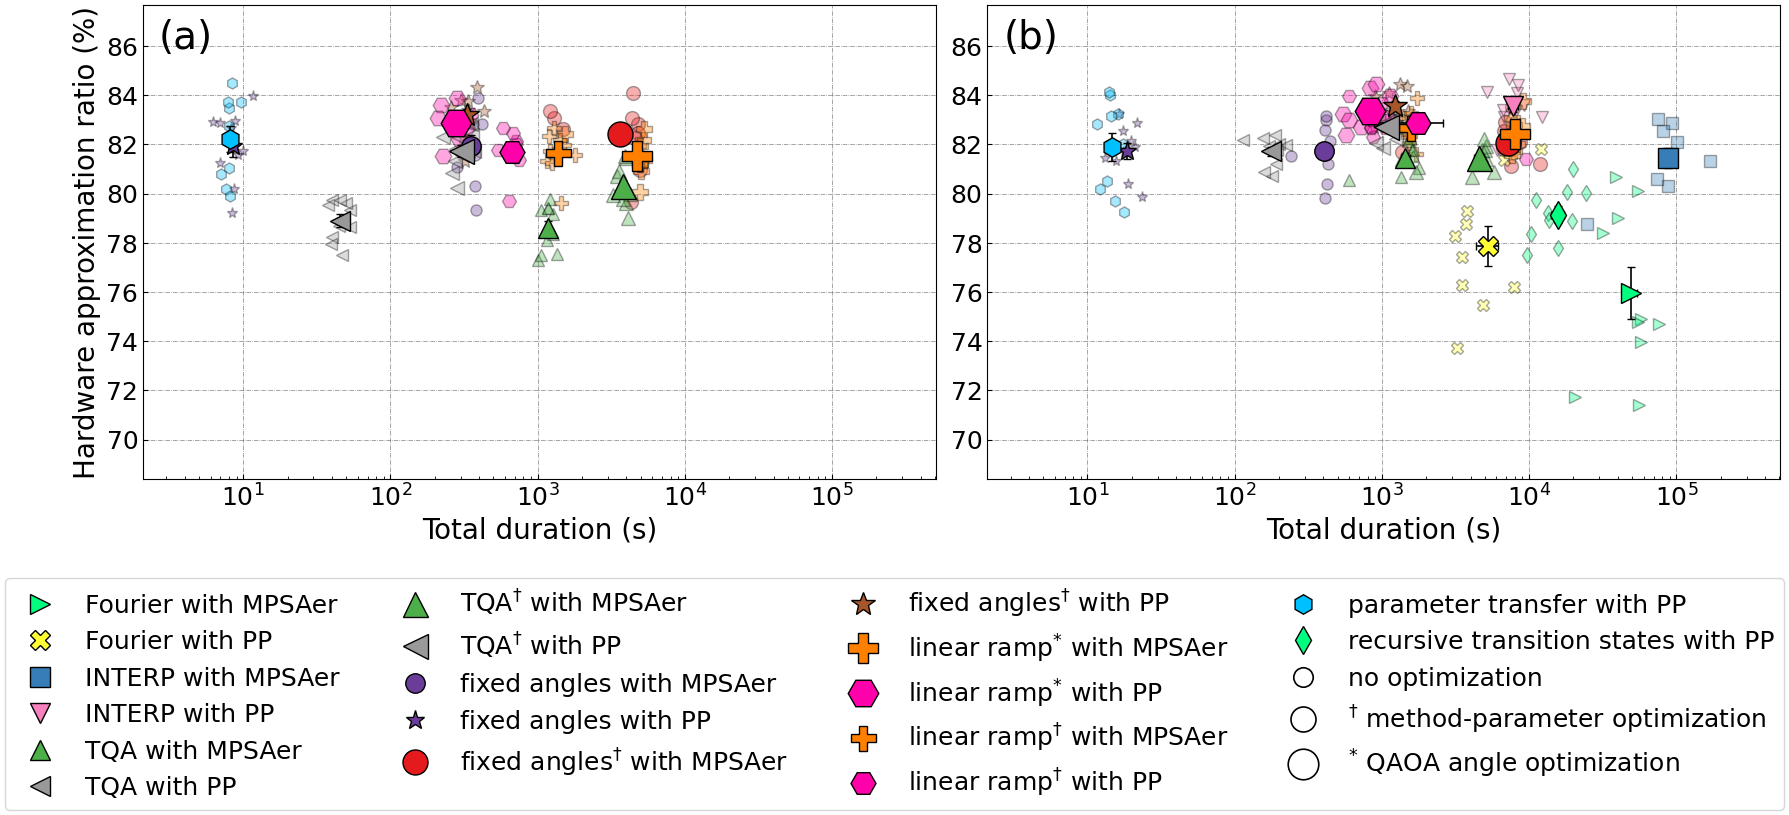

In [20]:
# Performance Plots (Performance Ratio vs Resource) — subplot layout
SAVE_DIR = "plots"

plot_data = prepare_ibm_qaoa_plot_data(df_SB_final, df_hardware, num_nodes)
df_points = plot_data["df_points"]
color_map = plot_data["color_map"]
shape_map = plot_data["shape_map"]
label_map = plot_data["label_map"]
_graph_id = plot_data["graph_id"]

plot_ibm_qaoa_performance_panels(plot_data, save_dir=SAVE_DIR)


Saved: plots/N144HH73_MC_performance_overlay.pdf


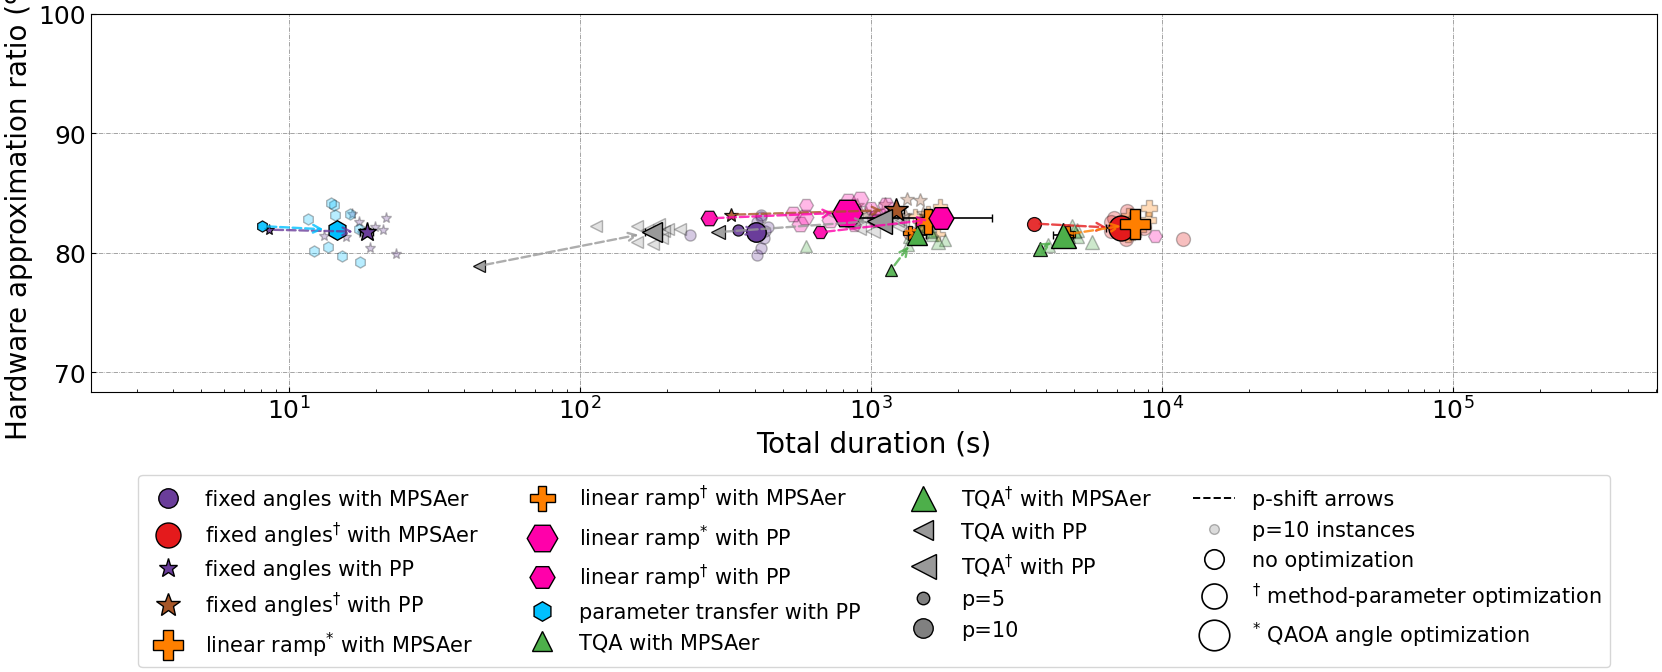

In [21]:
# Arrow overlay plot: transitions across p values in one panel
plot_ibm_qaoa_overlay(plot_data, save_dir=SAVE_DIR)

#### Mean training duration across instances with depth-wise breakdown
This plot summarizes the mean training duration (in seconds) averaged across problem instances for each QAOA depth (`job_p`). Each stacked bar decomposes the total training time into the outer initialization time and per-depth ‘brick’ contributions (depth steps). Error bars represent the standard error of the mean (SEM) across instances. Use this visualization to compare how different training methods scale with depth and to identify which depth steps dominate the training cost.

Saved: plots/N144HH73_MC_training_bricks.pdf


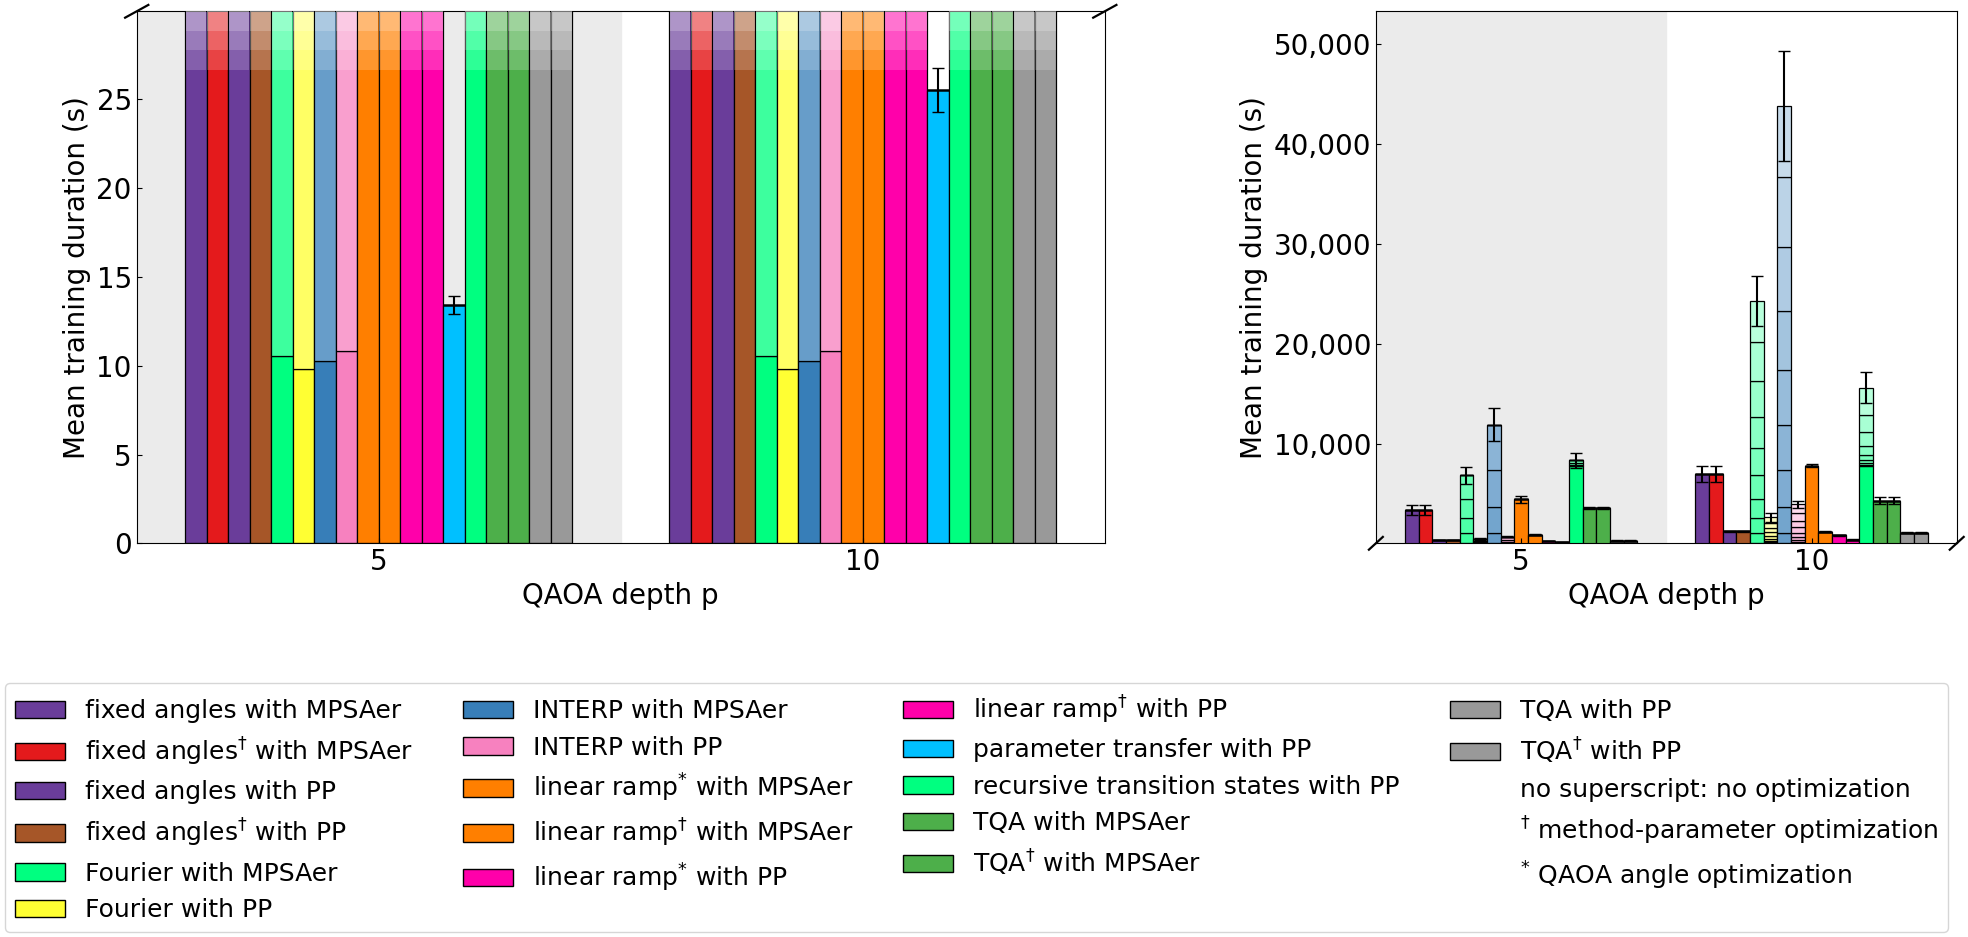

In [22]:
# Depth-wise training duration breakdown
agg, step_cols = prepare_training_bricks_data(df_flat, df_hardware_new)
plot_ibm_qaoa_training_bricks(
    agg,
    step_cols,
    color_map,
    label_map,
    _graph_id,
    save_dir=SAVE_DIR,
)

#### Recommendation Plot: Optimal Parameter Setting Strategy by Budget
This plot combines data from both QAOA depths to provide budget-driven recommendations. For any given total duration budget, the ladder-like outline (Pareto frontier) shows which parameter setting strategy achieves the best approximation ratio. The step function indicates the recommended method as the budget increases, helping practitioners choose the most cost-effective training strategy for their available computational resources.

Saved: plots/N144HH73_MC_recommendation.pdf


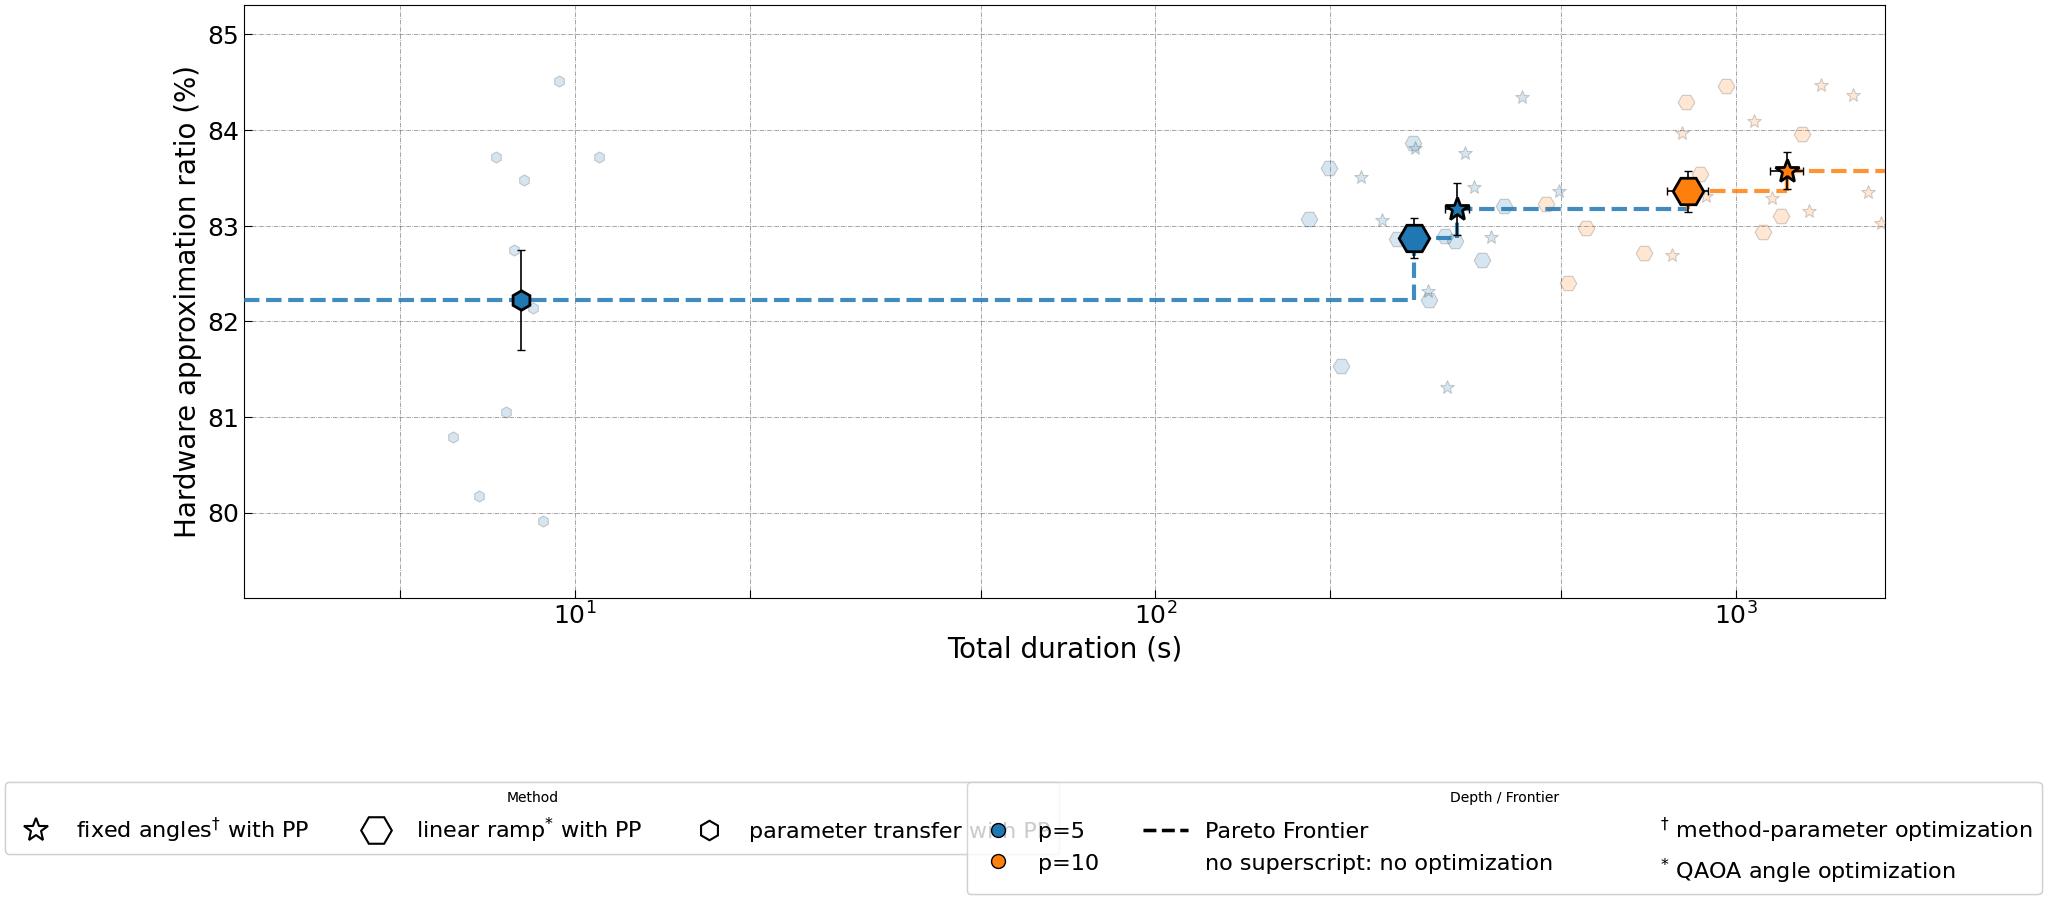


BUDGET-BASED RECOMMENDATIONS
Budget Range (s)          Recommended Method                  p     Approx Ratio   
--------------------------------------------------------------------------------
0 - 8                     PT_PP_AAA_5                         5     0.8222
8 - 279                   LR_PP_angleOpt_5                    5     0.8287
279 - 331                 FA_PP_opt_5                         5     0.8318
331 - 827                 LR_PP_angleOpt_10                   10    0.8336
> 827                     FA_PP_opt_10                        10    0.8357

FRONTIER POINTS
Method                              p     Duration (s)    Approx Ratio   
--------------------------------------------------------------------------------
PT_PP_AAA_5                         5     8.09            0.8222         
LR_PP_angleOpt_5                    5     278.54          0.8287         
FA_PP_opt_5                         5     330.76          0.8318         
LR_PP_angleOpt_10                   

In [23]:
# Recommendation Plot: Combining p's with Pareto Frontier
df_centroids, df_frontier = build_recommendation_data(df_points)
plot_ibm_qaoa_recommendation(
    df_points,
    df_frontier,
    color_map,
    shape_map,
    label_map,
    _graph_id,
    save_dir=SAVE_DIR,
)
print_budget_recommendations(df_frontier)